In [ ]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

SAMPLE_PATH = Path(
    "../data/processed/microservices_sample/"
    "microservices_traces_anonymized.csv"
)

FIGURE_DIR = Path("artifacts/figures/microservices")
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

In [5]:
### Célula 2 — carregar os eventos

events = pd.read_csv(
    SAMPLE_PATH,
    dtype=str,
    keep_default_na=False,
)

events["level"] = events["level"].str.upper()

events["text"] = (
    events["message"].fillna("")
    + " "
    + events["stack_trace"].fillna("")
)

events

,@timestamp,@version,level,level_value,logger_name,message,stack_trace,tc_app_name,tc_domain,tc_empresa,...,tc_trace_id,tc_uri_host,tc_uri_method,tc_uri_path,tc_uri_url,tc_user,tc_version,thread_name,traceId,text
0,2026-09-11T14:04:20.605482943Z,1,INFO,20000,br.com.triersistemas.cloud.integration.gestaoc...,Iniciando ProdutoRelationshipResolverImpl com ...,,integration-gestaocontrolados-backend,integration,3bdf62b4-f306-4095-96bc-a6e39c097887,...,02210645-0746-4da0-b4ea-adb8583708a3,,,,,desktop@dedita27395,1.6.111,InboxTaskExecutor-8,39bf4c5bc0fc0ef6ca4f22d6fb495efb,Iniciando ProdutoRelationshipResolverImpl com ...
1,2026-09-11T14:04:21.498044728Z,1,INFO,20000,br.com.triersistemas.cloud.integration.gestaoc...,Iniciando ProdutoRelationshipResolverImpl com ...,,integration-gestaocontrolados-backend,integration,3386684d-5af7-4928-86e8-17e39182bf7e,...,244b4d84-0dd5-4705-a8bf-84bb59cae066,,,,,desktop@f31157,1.6.111,InboxTaskExecutor-4,43bd1668fd7425ca5bda5cf118f97999,Iniciando ProdutoRelationshipResolverImpl com ...
2,2026-09-11T14:04:23.285113196Z,1,INFO,20000,br.com.triersistemas.cloud.it.sincronizacao.qu...,Cliente: 32084/<HEX_1>. 0 codigos de barras lo...,,it-sincronizacao-backend,it,,...,f8c484ae-2e84-4dac-95b0-ffa5940ffa46,,,,,admin@triercloudadmin,3.0.0,http-nio-80-exec-27,,Cliente: 32084/<HEX_1>. 0 codigos de barras lo...
3,2026-09-11T14:04:23.316486299Z,1,INFO,20000,br.com.triersistemas.cloud.integration.gestaoc...,Iniciando ProdutoRelationshipResolverImpl com ...,,integration-gestaocontrolados-backend,integration,3bdf62b4-f306-4095-96bc-a6e39c097887,...,02210645-0746-4da0-b4ea-adb8583708a3,,,,,desktop@dedita27395,1.6.111,InboxTaskExecutor-9,39bf4c5bc0fc0ef6ca4f22d6fb495efb,Iniciando ProdutoRelationshipResolverImpl com ...
4,2026-09-11T14:04:24.915917977Z,1,INFO,20000,br.com.triersistemas.cloud.database.core.Servi...,Starting Flyway migration for tenant: diasquei...,,cadastro-produto-backend,cadastro,fc9f1a02-aa5e-4f51-8881-b91a3dcc9bd4,...,b27c52af-cf04-4f41-ba8d-733a9831ff59,,,,,quelven@diasqueiroz27323,5.13.26,http-nio-80-exec-7,c82f61278014302d99c670a5c95c6234,Starting Flyway migration for tenant: diasquei...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
154731,2026-09-11T15:59:58.926864190Z,1,INFO,20000,br.com.triersistemas.cloud.compra.pedido.Entit...,"A carga inicial da entidade: 'produto', ordem:...",,compra-pedido-backend,compra,4d7d422f-c7d6-4c94-b18f-cf081d7a9745,...,135049af-d2d3-4f81-a809-4c8cad4eea92,,,,,desktop@f31626,2.1.7-SNAPSHOT.1788866313,vendaFinalizadaSubscriber_receive-3,f91aaf629d805282a466b75d0d06a456,"A carga inicial da entidade: 'produto', ordem:..."
154732,2026-09-11T15:59:58.928542294Z,1,INFO,20000,br.com.triersistemas.cloud.compra.pedido.entit...,Force: false. Tenant 'f31626' - Carga inicial ...,,compra-pedido-backend,compra,4d7d422f-c7d6-4c94-b18f-cf081d7a9745,...,135049af-d2d3-4f81-a809-4c8cad4eea92,,,,,desktop@f31626,2.1.7-SNAPSHOT.1788866313,vendaFinalizadaSubscriber_receive-3,f91aaf629d805282a466b75d0d06a456,Force: false. Tenant 'f31626' - Carga inicial ...
154733,2026-09-11T15:59:59.780421413Z,1,INFO,20000,br.com.triersistemas.cloud.integration.gestaoc...,Iniciando ProdutoRelationshipResolverImpl com ...,,integration-gestaocontrolados-backend,integration,3386684d-5af7-4928-86e8-17e39182bf7e,...,244b4d84-0dd5-4705-a8bf-84bb59cae066,,,,,desktop@f31157,1.6.111,InboxTaskExecutor-6,43bd1668fd7425ca5bda5cf118f97999,Iniciando ProdutoRelationshipResolverImpl com ...
154734,2026-09-11T15:59:59.918075276Z,1,INFO,20000,br.com.triersistemas.cloud.integration.gestaoc...,Iniciando ProdutoRelationshipResolverImpl com ...,,integration-gestaocontrolados-backend,integration,3bdf62b4-f306-4095-96bc-a6e39c097887,...,02210645-0746-4da0-b4ea-adb8583708a3,,,,,desktop@dedita27395,1.6.111,InboxTaskExecutor-1,39bf4c5bc0fc0ef6ca4f22d6fb495efb,Iniciando ProdutoRelationshipResolverImpl com ...


In [ ]:
### Célula 3 — extrair os sinais

events["has_stack_trace"] = (
    events["stack_trace"].str.strip().ne("")
)

events["has_exception_term"] = events["text"].str.contains(
    r"\bexception\b",
    case=False,
    regex=True,
)

events["has_failed_term"] = events["text"].str.contains(
    r"\bfailed\b",
    case=False,
    regex=True,
)

events["has_timeout_term"] = events["text"].str.contains(
    r"\btimeout\b",
    case=False,
    regex=True,
)

events["has_error_term"] = events["text"].str.contains(
    r"\berror\b",
    case=False,
    regex=True,
)


In [8]:
### Célula 4 — consolidar por trace

events = events[
    events["tc_trace_id"].str.strip().ne("")
].copy()

trace_signals = (
    events
    .groupby("tc_trace_id", sort=True)
    .agg(
        event_count=("tc_trace_id", "size"),
        info_count=("level", lambda s: (s == "INFO").sum()),
        warn_count=("level", lambda s: (s == "WARN").sum()),
        error_count=("level", lambda s: (s == "ERROR").sum()),
        has_stack_trace=("has_stack_trace", "max"),
        has_exception_term=("has_exception_term", "max"),
        has_failed_term=("has_failed_term", "max"),
        has_timeout_term=("has_timeout_term", "max"),
        has_error_term=("has_error_term", "max"),
        service_count=(
            "tc_service",
            lambda s: s[s != ""].nunique(),
        ),
    )
    .reset_index()
)

trace_signals.head()

,tc_trace_id,event_count,info_count,warn_count,error_count,has_stack_trace,has_exception_term,has_failed_term,has_timeout_term,has_error_term,service_count
0,00010db4-c32c-44a4-b010-d31214566aa1,1,1,0,0,False,False,False,False,False,1
1,00021ea9-f57b-448b-85db-e11b9f0e8a5a,4,4,0,0,False,False,False,False,False,1
2,0003d331-0143-40f3-8ad6-5b134e1dc0ba,1,1,0,0,False,False,False,False,False,1
3,000b87a9-b903-4a9d-b442-4c5a5114a47a,1,0,1,0,False,False,False,False,False,1
4,000e9a48-85c5-4aea-8c77-74dceb191d50,3,1,1,1,False,False,False,False,False,2


In [9]:
### Célula 5 — tabela de resumo

signal_columns = [
    "error_count",
    "warn_count",
    "has_stack_trace",
    "has_exception_term",
    "has_failed_term",
    "has_timeout_term",
    "has_error_term",
]

summary = pd.DataFrame(
    {
        "sinal": signal_columns,
        "traces_com_sinal": [
            int(trace_signals[column].gt(0).sum())
            for column in signal_columns
        ],
    }
)

summary["percentual"] = (
    summary["traces_com_sinal"]
    / len(trace_signals)
    * 100
)

summary

,sinal,traces_com_sinal,percentual
0,error_count,3219,16.114337
1,warn_count,4251,21.280537
2,has_stack_trace,202,1.011213
3,has_exception_term,49,0.245294
4,has_failed_term,9,0.045054
5,has_timeout_term,47,0.235282
6,has_error_term,263,1.316580


In [16]:
### Célula 6 — combinações de sinais
from datetime import datetime, timezone
import json
from pathlib import Path

trace_signals["text_signal_count"] = trace_signals[
    [
        "has_stack_trace",
        "has_exception_term",
        "has_failed_term",
        "has_timeout_term",
        "has_error_term",
    ]
].sum(axis=1)

combination_summary = (
    trace_signals
    .groupby(
        [
            "error_count",
            "warn_count",
            "has_stack_trace",
            "text_signal_count",
        ],
        dropna=False,
    )
    .size()
    .reset_index(name="trace_count")
    .sort_values("trace_count", ascending=False)
)

combination_summary.head(20)



manifest = {
    "stage": "microservices_trace_signal_combinations",
    "generated_at": datetime.now(timezone.utc).isoformat(),
    "input": str(SAMPLE_PATH),
    "traces_analyzed": int(len(trace_signals)),
    "events_analyzed": int(len(events)),
    "combination_rows": int(len(combination_summary)),
    "top_combinations": combination_summary.head(20).to_dict(
        orient="records"
    ),
}

manifest_path = Path("../data/processed/microservices_sample/microservices_signal_combinations_manifest.json")

manifest_path.write_text(
    json.dumps(
        manifest,
        indent=2,
        ensure_ascii=False,
    ),
    encoding="utf-8",
)

print(f"Manifesto salvo em: {manifest_path}")

Manifesto salvo em: ../data/processed/microservices_sample/microservices_signal_combinations_manifest.json


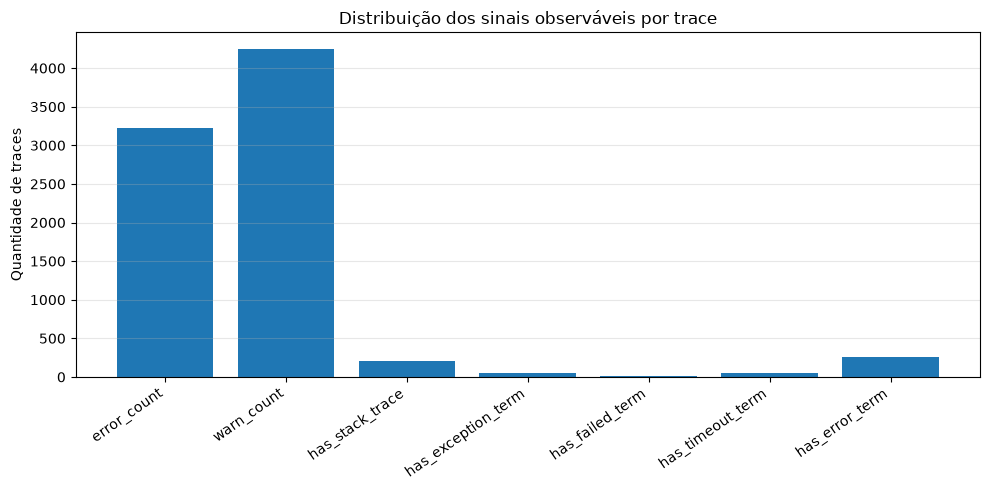

In [11]:
### Célula 7 — gráfico dos sinais

plt.figure(figsize=(10, 5))

plt.bar(
    summary["sinal"],
    summary["traces_com_sinal"],
)

plt.xticks(rotation=35, ha="right")
plt.ylabel("Quantidade de traces")
plt.title("Distribuição dos sinais observáveis por trace")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()

plt.savefig(
    FIGURE_DIR / "microservices_signal_distribution.png",
    dpi=300,
)

plt.show()

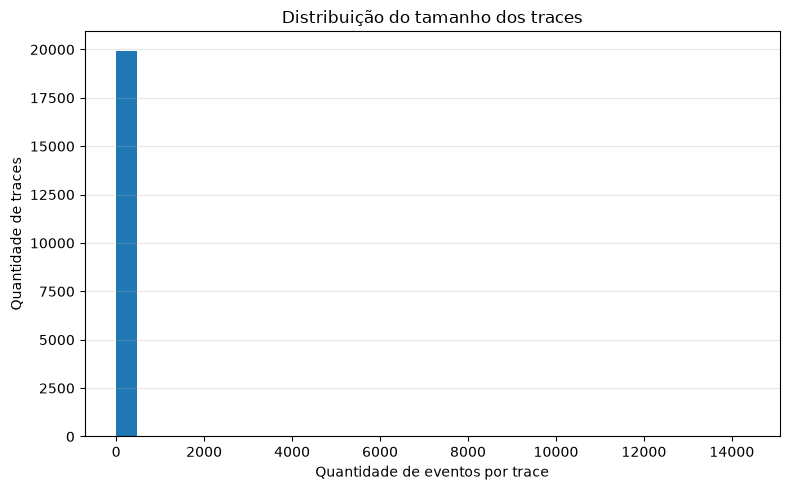

In [12]:
### Célula 8 — distribuição de eventos por trace

plt.figure(figsize=(8, 5))

plt.hist(
    trace_signals["event_count"],
    bins=30,
)

plt.xlabel("Quantidade de eventos por trace")
plt.ylabel("Quantidade de traces")
plt.title("Distribuição do tamanho dos traces")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()

plt.savefig(
    FIGURE_DIR / "microservices_trace_event_count.png",
    dpi=300,
)

plt.show()

In [13]:
### Célula 9 — exportar tabelas

trace_signals.to_csv(
    FIGURE_DIR / "microservices_trace_signals.csv",
    index=False,
)

summary.to_csv(
    FIGURE_DIR / "microservices_signal_summary.csv",
    index=False,
)

combination_summary.to_csv(
    FIGURE_DIR / "microservices_signal_combinations.csv",
    index=False,
)